# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
import tarfile
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
plt.show()

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
dataset_dir = 'scripts/datasets'
tar_filename = "cifar-10-python.tar.gz"
url = "https://www.cs.toronto.edu/~kriz/" + tar_filename
tar_path = os.path.join(dataset_dir, tar_filename)
final_folder = os.path.join(dataset_dir, 'cifar-10-batches-py')

if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)
    print(f"Directory {dataset_dir} created.")

if not os.path.exists(final_folder):
    print("Downloading CIFAR-10... Please wait (approx. 170MB).")
    urllib.request.urlretrieve(url, tar_path)
    
    print("Extracting files...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=dataset_dir)
    
    os.remove(tar_path)
    print(f"Successfully downloaded and extracted to {final_folder}")
else:
    print("Dataset already exists, skipping download.")

Dataset already exists, skipping download.


In [3]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

c:\Users\VikiS\lastSem\ai\secondPart\lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



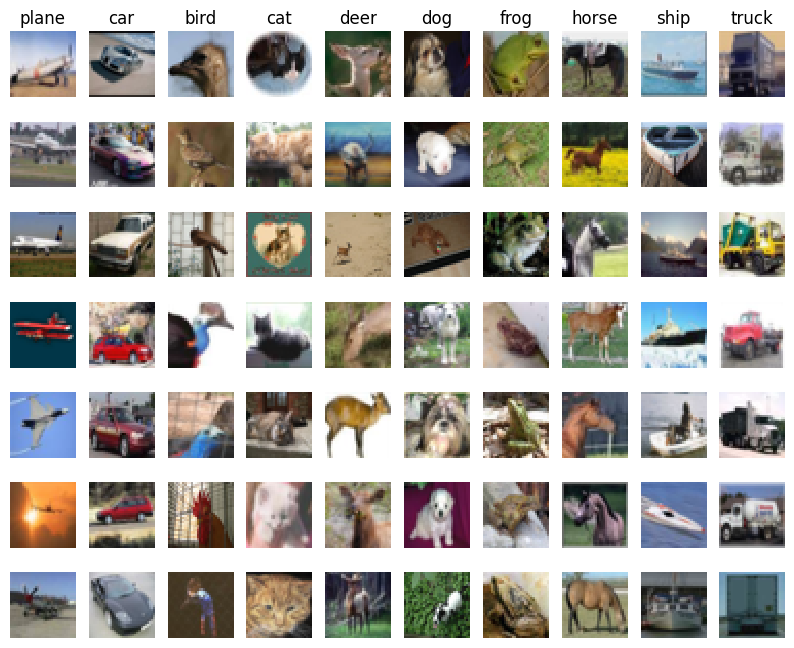

In [4]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].reshape(32,32,3).astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [5]:
#load_CIFAR10() уже разделяет батчи, поэтому в этой ячейке не будет разделения
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [6]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [7]:
dists = classifier.compute_distances_no_loops(X_test)

y_test_pred = classifier.predict_labels(dists, k=1)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


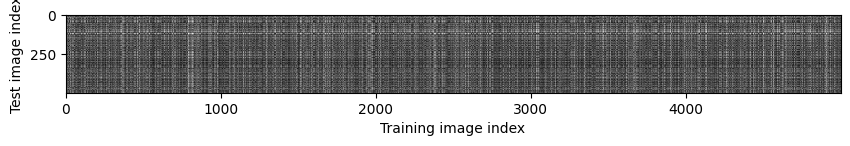

In [8]:
plt.imshow(dists, interpolation='none')
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [9]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))

Got 137 / 500 correct => accuracy: 0.274000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1, accuracy = 0.274000
k = 3, accuracy = 0.272000
k = 5, accuracy = 0.278000
k = 8, accuracy = 0.274000
k = 10, accuracy = 0.282000
k = 12, accuracy = 0.256000
k = 15, accuracy = 0.272000
k = 20, accuracy = 0.272000
k = 50, accuracy = 0.252000
k = 100, accuracy = 0.222000


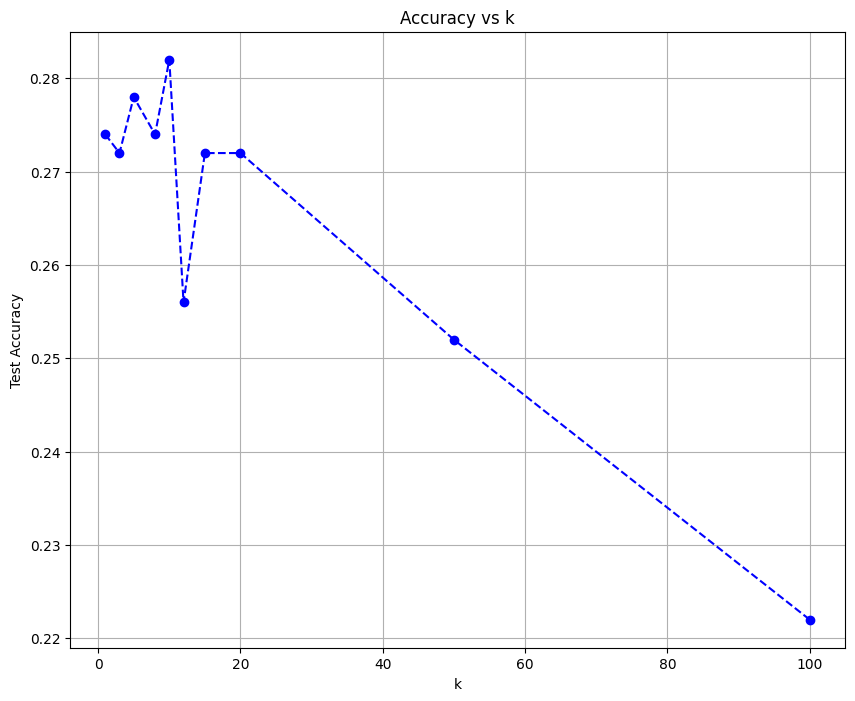

In [10]:
# 1.8 Постройте график зависимости доли правильно классифицированных изображений 
# от числа соседей, используемых при классификации.

k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]
accuracies = []

for k in k_choices:
    # Предсказываем для текущего k
    y_test_pred = classifier.predict(X_test, k=k, num_loops=0)
    # Считаем точность
    num_correct = np.sum(y_test_pred == y_test)
    accuracy = float(num_correct) / num_test
    accuracies.append(accuracy)
    print('k = %d, accuracy = %f' % (k, accuracy))

plt.plot(k_choices, accuracies, marker='o', color='b', linestyle='--')
plt.title('Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [11]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        # Формируем тренировочную выборку из всех фолдов, кроме текущего
        X_train_cv = np.vstack(X_train_folds[:fold] + X_train_folds[fold+1:])
        y_train_cv = np.hstack(y_train_folds[:fold] + y_train_folds[fold+1:])
        
        # Валидационная выборка - текущий фолд
        X_val_cv = X_train_folds[fold]
        y_val_cv = y_train_folds[fold]
        
        knn = KNearestNeighbor()
        knn.train(X_train_cv, y_train_cv)
        
        y_val_pred = knn.predict(X_val_cv, k=k)
        accuracy = np.mean(y_val_pred == y_val_cv)
        k_to_accuracies[k].append(accuracy)

# Вывод результатов
for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

k = 1, accuracy = 0.263000
k = 1, accuracy = 0.257000
k = 1, accuracy = 0.264000
k = 1, accuracy = 0.278000
k = 1, accuracy = 0.266000
k = 3, accuracy = 0.239000
k = 3, accuracy = 0.249000
k = 3, accuracy = 0.240000
k = 3, accuracy = 0.266000
k = 3, accuracy = 0.254000
k = 5, accuracy = 0.248000
k = 5, accuracy = 0.266000
k = 5, accuracy = 0.280000
k = 5, accuracy = 0.292000
k = 5, accuracy = 0.280000
k = 8, accuracy = 0.262000
k = 8, accuracy = 0.282000
k = 8, accuracy = 0.273000
k = 8, accuracy = 0.290000
k = 8, accuracy = 0.273000
k = 10, accuracy = 0.265000
k = 10, accuracy = 0.296000
k = 10, accuracy = 0.276000
k = 10, accuracy = 0.284000
k = 10, accuracy = 0.280000
k = 12, accuracy = 0.260000
k = 12, accuracy = 0.295000
k = 12, accuracy = 0.279000
k = 12, accuracy = 0.283000
k = 12, accuracy = 0.280000
k = 15, accuracy = 0.252000
k = 15, accuracy = 0.289000
k = 15, accuracy = 0.278000
k = 15, accuracy = 0.282000
k = 15, accuracy = 0.274000
k = 20, accuracy = 0.270000
k = 20, accu


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [12]:
# 1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.

# 1. Находим лучшее значение k на основе среднего значения точности из кросс-валидации
# Мы берем словарь k_to_accuracies из предыдущего пункта и считаем среднее для каждого k
best_k = sorted(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))[-1]

print('Best k found during cross-validation: %d' % best_k)

# 2. Инициализируем классификатор
classifier = KNearestNeighbor()
# "Обучаем" на всей тренировочной выборке (в kNN это просто запоминание данных)
classifier.train(X_train, y_train)

# 3. Предсказываем метки для тестовой выборки с использованием лучшего k
# Используем num_loops=0 для быстрой векторной реализации
y_test_pred = classifier.predict(X_test, k=best_k, num_loops=0)

# 4. Вычисляем и выводим финальную точность на тестовой выборке
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Final test set accuracy: %f (Got %d / %d correct)' % (accuracy, num_correct, num_test))

Best k found during cross-validation: 10
Final test set accuracy: 0.282000 (Got 141 / 500 correct)


1.11 Сделайте выводы по результатам 1 части задания.

In [13]:
#kNN: Хорошо работает на простых данных, но на CIFAR-10 точность низкая (около 30%), 
# так как L2 расстояние плохо отражает схожесть сложных изображений.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [14]:
# 3.1 Разделите данные на обучающую, тестовую и валидационную выборки.

# ВАЖНО: Перезагружаем данные, так как в части kNN мы их обрезали до 5000
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_CIFAR10(cifar10_dir)

# Теперь задаем размеры выборок
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Валидационная выборка (последние 1000 из тренировочных)
mask = range(num_training, num_training + num_validation)
X_val = X_train_raw[mask]
y_val = y_train_raw[mask]

# Обучающая выборка (первые 49000)
mask = range(num_training)
X_train = X_train_raw[mask]
y_train = y_train_raw[mask]

# Тестовая выборка (возьмем 1000 для скорости, или все 10000)
mask = range(num_test)
X_test = X_test_raw[mask]
y_test = y_test_raw[mask]

# Dev выборка (случайные 500 из обучающей для быстрой проверки градиента)
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Преобразуем в одномерные массивы (Flatten)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Train data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Train data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [15]:
# 3.2 Вычитание среднего изображения
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# 3.3 Bias Trick: Добавляем колонку из единиц, чтобы матрица W (3073, 10) 
# могла умножаться на наши данные.
# Это превращает вектор признаков из 3072 в 3073.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print("New shapes:")
print('Train data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape) 
# Теперь везде должно быть (N, 3073)

New shapes:
Train data shape:  (49000, 3073)
Validation data shape:  (1000, 3073)
Test data shape:  (1000, 3073)
dev data shape:  (500, 3073)


3.4 Реализуйте функции в classifiers/softmax.py




In [16]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.311318
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [17]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -2.655921 analytic: -2.655921, relative error: 6.696895e-10
numerical: 1.153287 analytic: 1.153286, relative error: 4.315679e-08
numerical: 4.163403 analytic: 4.163403, relative error: 9.649341e-09
numerical: -2.352252 analytic: -2.352253, relative error: 3.044478e-08
numerical: 0.665171 analytic: 0.665170, relative error: 6.651386e-08
numerical: -0.561412 analytic: -0.561412, relative error: 8.573216e-08
numerical: -0.999393 analytic: -0.999393, relative error: 3.565115e-08
numerical: -3.244014 analytic: -3.244014, relative error: 8.171455e-10
numerical: 1.567237 analytic: 1.567237, relative error: 1.328288e-08
numerical: -1.797634 analytic: -1.797634, relative error: 5.968335e-09
numerical: -0.601427 analytic: -0.601427, relative error: 8.123132e-08
numerical: -5.435864 analytic: -5.435864, relative error: 5.692731e-10
numerical: -0.177333 analytic: -0.177333, relative error: 2.050031e-08
numerical: 1.071723 analytic: 1.071723, relative error: 3.519499e-08
numerical: -0.78

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [18]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.311318e+00 computed in 0.065311s
vectorized loss: 2.311318e+00 computed in 0.005565s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

In [19]:
# 3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.
from scripts.classifiers.linear_classifier import Softmax

# Создаем пробную модель
softmax_test_model = Softmax()
# Обучаем быстро (всего 500 итераций)
softmax_test_model.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                         num_iters=500, verbose=True)

# Проверяем на тесте
y_test_pred = softmax_test_model.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax test set accuracy (initial run): %f' % test_accuracy)

iteration 0 / 500: loss 392.646104
iteration 100 / 500: loss 236.906298
iteration 200 / 500: loss 143.986782
iteration 300 / 500: loss 87.875490
iteration 400 / 500: loss 54.074212
Softmax test set accuracy (initial run): 0.267000


3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [20]:
from scripts.classifiers.linear_classifier import Softmax

results = {}
best_val = -1
best_softmax = None

learning_rates = [1e-7, 5e-7, 1e-6]
regularization_strengths = [2.5e4, 5e4]

# 3.9 Цикл кросс-валидации
for lr in learning_rates:
    for reg in regularization_strengths:
        # 1. Создаем новый экземпляр классификатора
        softmax_model = Softmax()
        
        # 2. Обучаем модель на обучающей выборке
        # num_iters можно поставить 1500 для более точного результата
        softmax_model.train(X_train, y_train, learning_rate=lr, reg=reg,
                            num_iters=1500, verbose=False)
        
        # 3. Предсказываем на тренировочных и валидационных данных
        y_train_pred = softmax_model.predict(X_train)
        train_accuracy = np.mean(y_train == y_train_pred)
        
        y_val_pred = softmax_model.predict(X_val)
        val_accuracy = np.mean(y_val == y_val_pred)
        
        # 4. Сохраняем результаты
        results[(lr, reg)] = (train_accuracy, val_accuracy)
        
        # 5. Запоминаем лучшую модель
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax_model # Вот здесь мы определяем ту самую переменную!

# Вывод результатов
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.349163 val accuracy: 0.365000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.328612 val accuracy: 0.345000
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.349510 val accuracy: 0.366000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.325980 val accuracy: 0.345000
lr 1.000000e-06 reg 2.500000e+04 train accuracy: 0.344204 val accuracy: 0.352000
lr 1.000000e-06 reg 5.000000e+04 train accuracy: 0.325265 val accuracy: 0.332000
best validation accuracy achieved during cross-validation: 0.366000


3.10 Сделайте выводы по третьей части задания

In [21]:
#Softmax: Более продвинутый метод. Векторизованная реализация работает значительно быстрее наивной. 
# С помощью подбора параметров learning_rate и reg можно добиться точности выше 35-40% даже на линейной модели.